# 🛒 E-commerce Sales Analysis

## 📌 Project Overview

This project performs an exploratory data analysis (EDA) of e-commerce sales data to identify sales trends, profitability patterns, customer purchasing behavior, and factors affecting business performance.

### Objectives

- Understand the structure and quality of the dataset
- Analyze revenue and profit trends
- Identify high-performing categories and products
- Compare cities, payment methods, and sales channels
- Analyze the relationship between discounts and profit
- Identify loss-making orders
- Generate actionable business recommendations

### Tools & Technologies

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [3]:
!mamba install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 2.639 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.6    np23py313h124dbc7_0  emscripten-forge-4x
+ python-tzdata  2026.5   pyh5ded981_0         conda-forge
- pip            26.2.1   pyh145f28c_0         conda-forge


## 1. Import Libraries

In [136]:
import pandas as pd

## 2. Load Dataset

In [137]:
df = pd.read_csv("ecommerce_sales_analysis_dataset.csv")

## 3. Data Understanding

In [138]:
df.head() #Look at the first 5 rows

,order_id,order_date,customer_id,city,category,product,quantity,unit_price,payment_method,channel,discount_pct,revenue,cost,profit
0,1001,2026-04-13,545,Mumbai,Beauty,Headphones,4,799,UPI,Website,20,2556.8,1830.19,726.61
1,1002,2026-06-29,557,Mumbai,Electronics,T-Shirt,2,799,Credit Card,Website,10,1438.2,1240.01,198.19
2,1003,2026-04-03,553,Mumbai,Home,Watch,4,299,Debit Card,Website,10,1076.4,755.50,320.90
3,1004,2026-01-15,506,Delhi,Beauty,Laptop,3,1499,Debit Card,Mobile App,10,4047.3,3684.07,363.23
4,1005,2026-04-17,528,Pune,Clothing,Headphones,3,299,UPI,Website,10,807.3,635.05,172.25


In [139]:
df.tail()   #Look at the last 5 rows

,order_id,order_date,customer_id,city,category,product,quantity,unit_price,payment_method,channel,discount_pct,revenue,cost,profit
147,1148,2026-01-28,555,Bhubaneswar,Clothing,Laptop,3,1499,Debit Card,Website,15,3822.45,3821.58,0.87
148,1149,2026-03-07,509,Delhi,Electronics,Mixer,1,7999,UPI,Mobile App,0,7999.00,5733.22,2265.78
149,1150,2026-06-19,541,Delhi,Home,Shoes,2,499,Debit Card,Mobile App,20,798.40,690.58,107.82
150,1013,2026-04-10,555,Pune,Beauty,T-Shirt,3,4999,Credit Card,Website,20,11997.60,9130.68,2866.92
151,1036,2026-02-24,524,Ahmedabad,Electronics,Laptop,3,799,Debit Card,Mobile App,20,1917.60,1780.68,136.92


In [140]:
df.shape #STEP 2 — Check the size

(152, 14)

In [141]:
df.info()   #STEP 4 —Check data types and missing values

<class 'pandas.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        152 non-null    int64  
 1   order_date      152 non-null    str    
 2   customer_id     152 non-null    int64  
 3   city            150 non-null    str    
 4   category        152 non-null    str    
 5   product         152 non-null    str    
 6   quantity        152 non-null    int64  
 7   unit_price      152 non-null    int64  
 8   payment_method  149 non-null    str    
 9   channel         152 non-null    str    
 10  discount_pct    152 non-null    int64  
 11  revenue         152 non-null    float64
 12  cost            152 non-null    float64
 13  profit          152 non-null    float64
dtypes: float64(3), int64(5), str(6)
memory usage: 13.1 KB


In [142]:
df.columns #See all column names

Index(['order_id', 'order_date', 'customer_id', 'city', 'category', 'product',
       'quantity', 'unit_price', 'payment_method', 'channel', 'discount_pct',
       'revenue', 'cost', 'profit'],
      dtype='str')

## 4. Data Quality Check

Before performing the analysis, the dataset was checked for missing values, duplicate records, incorrect data types, and categorical inconsistencies.

In [143]:
df.isnull().sum()   #STEP 5 —Check missing values directly

order_id          0
order_date        0
customer_id       0
city              2
category          0
product           0
quantity          0
unit_price        0
payment_method    3
channel           0
discount_pct      0
revenue           0
cost              0
profit            0
dtype: int64

In [144]:
#STEP 6 — Check duplicate rows
df.duplicated().sum()

np.int64(2)

## 5. Descriptive Statistics

Descriptive statistics were used to understand the distribution and central tendency of the numerical variables, including quantity, unit price, discount, revenue, cost, and profit.

In [145]:
#STEP 7 — Basic numerical statistics
df.describe()

,order_id,customer_id,quantity,unit_price,discount_pct,revenue,cost,profit
count,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000
mean,1074.828947,532.039474,2.453947,2373.342105,10.197368,4975.400000,3952.419868,1022.980132
std,43.568896,18.586786,1.167092,2480.880444,7.207464,5967.911991,4811.612727,1468.965974
min,1001.000000,501.000000,1.000000,299.000000,0.000000,239.200000,172.250000,-227.960000
25%,1036.750000,516.750000,1.000000,499.000000,5.000000,1076.400000,936.925000,169.790000
50%,1074.500000,532.000000,2.000000,1249.000000,10.000000,2548.300000,1889.450000,463.770000
75%,1112.250000,549.000000,4.000000,2499.000000,15.000000,6479.125000,5242.410000,1177.707500
max,1150.000000,560.000000,4.000000,7999.000000,20.000000,30396.200000,25863.020000,7892.200000


In [146]:
#STEP 8 — Understand categorical columns
df['city'].unique()    #unique()→shows the actual categories.

<StringArray>
['Mumbai', 'Delhi', 'Pune', 'Ahmedabad', nan, 'Bengaluru', 'Bhubaneswar']
Length: 7, dtype: str

In [147]:
df['city'].nunique()   #nunique() → tells how many different categories exist.

6

In [148]:
df['city'].value_counts()   #This tells you how many orders came from each city.

city
Pune           32
Ahmedabad      27
Mumbai         25
Delhi          25
Bengaluru      22
Bhubaneswar    19
Name: count, dtype: int64

In [149]:
!pip install matplotlib

mambajs 0.21.4

Process pip requirements ...

Requirement matplotlib already handled by conda/micromamba/mamba.


In [150]:
import matplotlib.pyplot as plt

## 6. Outlier Analysis

Box plots and the Interquartile Range (IQR) method were used to identify unusually high or low revenue values.

Outliers were investigated to determine whether they represented genuine high-value orders or potential data-quality issues.

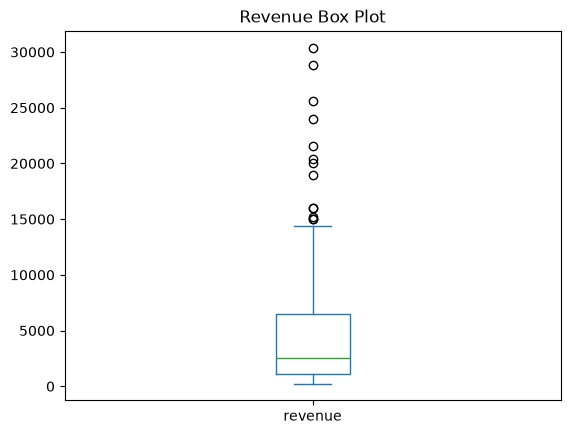

In [151]:
#Outlier Analysis- Box plot
df["revenue"].plot(kind="box")
plt.title("Revenue Box Plot")
plt.show()

In [152]:
Q1= df["revenue"].quantile(0.25)
Q3=df["revenue"].quantile(0.75)

IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+2.5*IQR

print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("Lower Bound:",lower_bound)
print("Upper Bound:",upper_bound)

Q1: 1076.4
Q3: 6479.125
IQR: 5402.725
Lower Bound: -7027.6875
Upper Bound: 19985.9375


In [153]:
revenue_outliers=df[
    (df["revenue"]<lower_bound) |
    (df["revenue"]>upper_bound)
    ]
revenue_outliers

,order_id,order_date,customer_id,city,category,product,quantity,unit_price,payment_method,channel,discount_pct,revenue,cost,profit
47,1048,2026-01-14,552,Mumbai,Beauty,Mixer,4,7999,Debit Card,Mobile App,10,28796.40,25863.02,2933.38
91,1092,2026-01-09,548,Pune,Clothing,T-Shirt,4,4999,Credit Card,Mobile App,0,19996.00,12103.80,7892.20
125,1126,2026-04-13,523,Delhi,Clothing,Mixer,3,7999,Cash,Website,15,20397.45,13940.53,6456.92
132,1133,2026-06-28,516,Pune,Home,Headphones,3,7999,UPI,Mobile App,10,21597.30,13822.55,7774.75
136,1137,2026-04-06,552,Bengaluru,Electronics,Skincare,4,7999,Credit Card,Website,20,25596.80,24883.63,713.17
141,1142,2026-01-29,548,Pune,Beauty,Laptop,4,7999,Debit Card,Website,5,30396.20,23805.01,6591.19
144,1145,2026-06-09,537,Delhi,Beauty,Laptop,3,7999,Credit Card,Website,0,23997.00,18021.15,5975.85


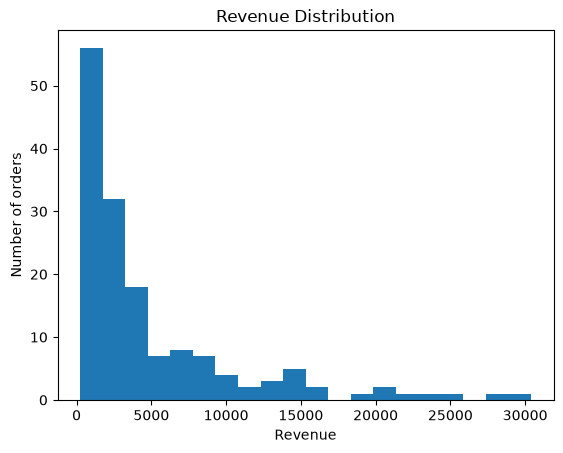

In [154]:
#STEP 11 — Histogram

import matplotlib.pyplot as plt

df["revenue"].plot(kind="hist",bins=20)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of orders")
plt.show()

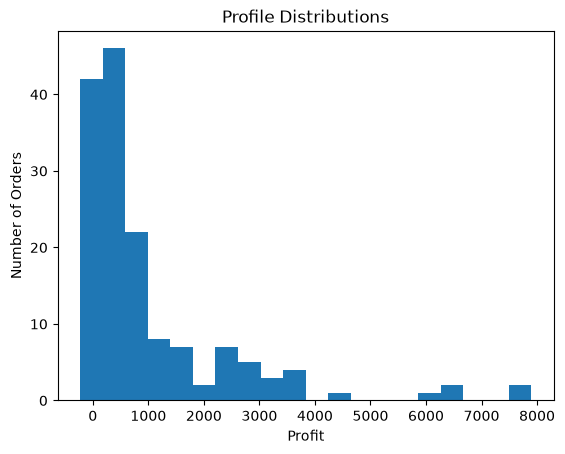

In [155]:
#STEP 12 — Analyze Profit Distribution

df["profit"].plot(kind="hist",bins=20)

plt.title("Profile Distributions")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")
plt.show()

## 7. Time-Based Analysis

The order date was converted into a datetime format to analyze sales performance over time.

Monthly revenue and profit were analyzed to identify changes and trends in business performance.

In [156]:
#STEP 13 — Time Analysis

df["order_date"]

<StringDtype(storage='python', na_value=nan)>

In [157]:
df["order_date"]=pd.to_datetime(df["order_date"])

In [158]:
df["order_date"].dtype

dtype('<M8[us]')

In [159]:
print("Start date:", df["order_date"].min())
print("End date:",df["order_date"].max())

Start date: 2026-01-01 00:00:00
End date: 2026-06-29 00:00:00


In [160]:
df["month"]=df["order_date"].dt.to_period("M")


In [161]:
df[["order_date","month"]].head()

,order_date,month
0,2026-04-13,2026-04
1,2026-06-29,2026-06
2,2026-04-03,2026-04
3,2026-01-15,2026-01
4,2026-04-17,2026-04


In [162]:
#STEP 15 — Monthly Revenue

monthly_revenue = df.groupby("month")["revenue"].sum()
monthly_revenue

month
2026-01    175269.75
2026-02    107448.45
2026-03    105660.70
2026-04    145875.85
2026-05    123585.05
2026-06     98421.00
Freq: M, Name: revenue, dtype: float64

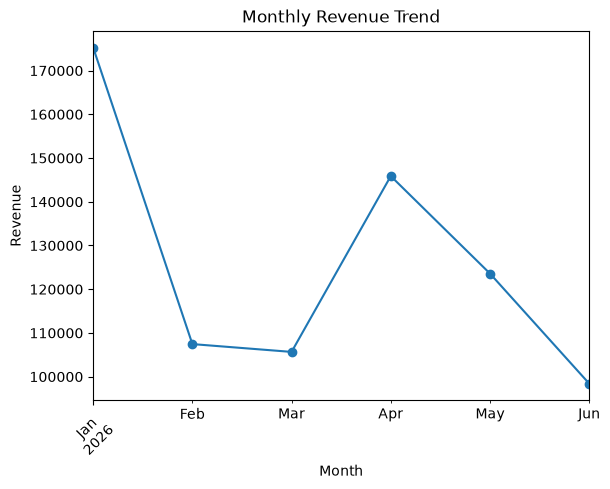

In [163]:
monthly_revenue.plot(kind ="line",marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [164]:
#STEP 16 — Monthly Profit

monthly_profit=df.groupby("month")["profit"].sum()
monthly_profit

month
2026-01    36826.57
2026-02    20340.84
2026-03    19398.97
2026-04    30858.21
2026-05    23559.84
2026-06    24508.55
Freq: M, Name: profit, dtype: float64

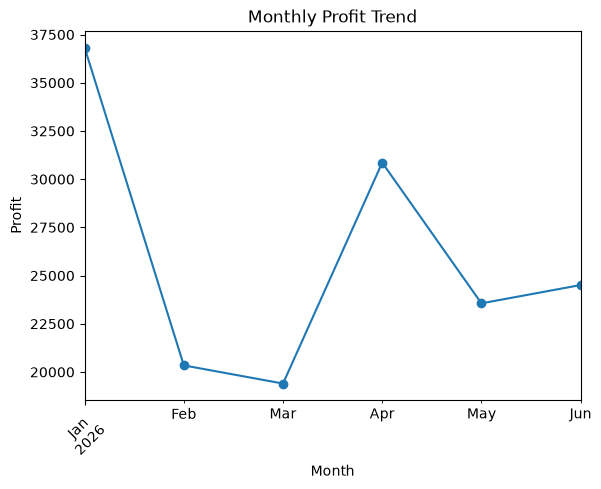

In [165]:
monthly_profit.plot(kind="line",marker="o")

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

## 8. Category Analysis

Sales performance was analyzed across product categories using order volume, revenue, and profit.

This helps identify which categories contribute most to overall business performance.

In [166]:
#STEP 17 — Category Analysis

category_orders=df["category"].value_counts()
category_orders

category
Beauty         44
Electronics    41
Clothing       37
Home           30
Name: count, dtype: int64

In [167]:
category_revenue=df.groupby("category")["revenue"].sum().sort_values(ascending=False)
category_revenue

category
Beauty         249267.90
Clothing       194500.25
Electronics    184721.45
Home           127771.20
Name: revenue, dtype: float64

In [168]:
category_profit=df.groupby("category")["profit"].sum().sort_values(ascending=False)
category_profit

category
Beauty         51512.88
Clothing       42586.92
Home           32002.87
Electronics    29390.31
Name: profit, dtype: float64

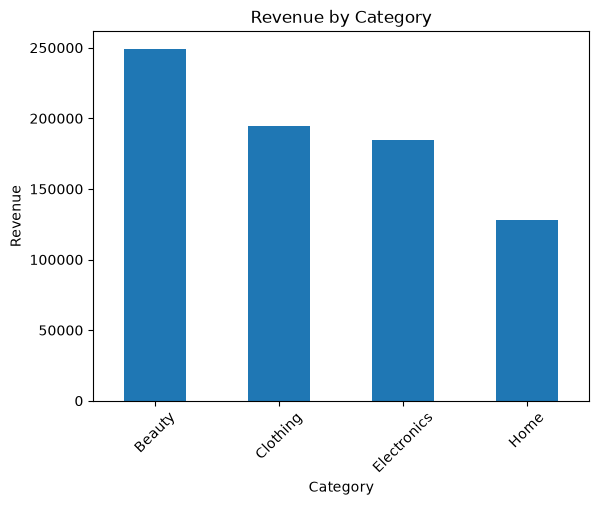

In [169]:
category_revenue.plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

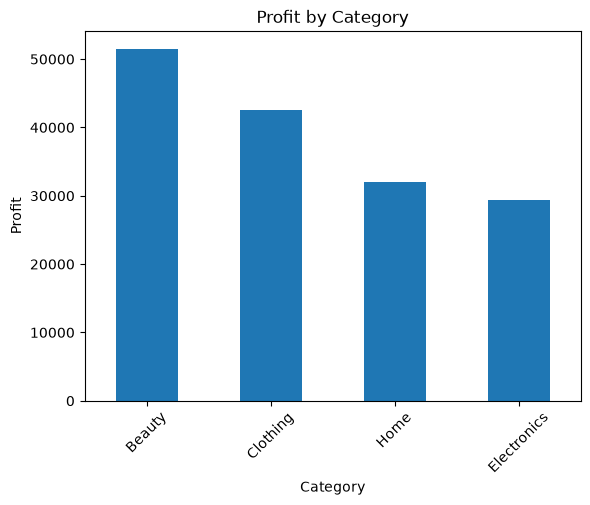

In [170]:
category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

## 9. City Analysis

Sales performance was analyzed across different cities using order volume, revenue, and profit.

This helps identify the strongest-performing locations and potential opportunities for regional growth.

In [171]:
#STEP 20 — City Analysis 🏙️

#20.1 — Orders by city(This tells us how many orders came from each city.)
city_orders=df["city"].value_counts()
city_orders

city
Pune           32
Ahmedabad      27
Mumbai         25
Delhi          25
Bengaluru      22
Bhubaneswar    19
Name: count, dtype: int64

In [172]:
#20.2 — Revenue by city
city_revenue=df.groupby("city")["revenue"].sum().sort_values(ascending=False)
city_revenue

city
Pune           226559.25
Bengaluru      128016.10
Delhi          121574.35
Mumbai         119470.90
Ahmedabad       79735.15
Bhubaneswar     77148.00
Name: revenue, dtype: float64

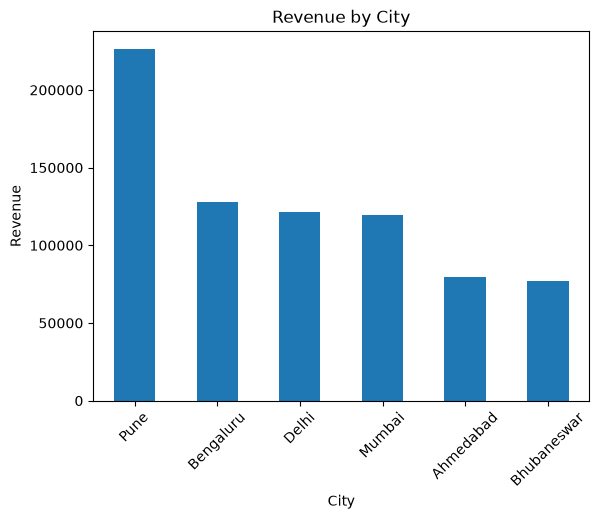

In [173]:
city_revenue.plot(kind="bar")

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [174]:
#20.3 — Profit by city

city_profit=df.groupby("city")["profit"].sum().sort_values(ascending=False)
city_profit                    

city
Pune           55399.03
Delhi          31334.11
Mumbai         21488.88
Bengaluru      17288.96
Ahmedabad      15550.51
Bhubaneswar    13297.07
Name: profit, dtype: float64

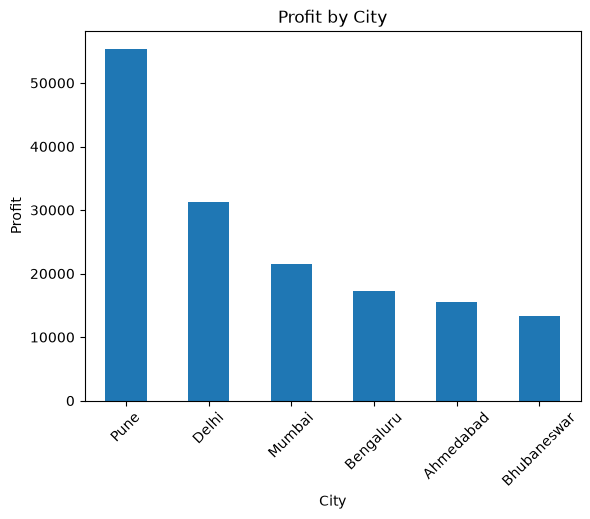

In [175]:
city_profit.plot(kind="bar")
plt.title("Profit by City")
plt.xlabel("City")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

## 10. Product Analysis

Sales performance was analyzed at the product level using order volume, revenue, and profit.

This helps identify high-performing products and products that may require further investigation.

In [176]:
#STEP 21 — Product Analysis
  #21.1 — Orders by product

product_orders=df["product"].value_counts()
product_orders

product
Mixer         26
Laptop        25
Headphones    21
T-Shirt       18
Watch         18
Shoes         18
Backpack      15
Skincare      11
Name: count, dtype: int64

In [177]:
#21.2 — Revenue by product
product_revenue = df.groupby("product")["revenue"].sum().sort_values(ascending=False)
product_revenue

product
Laptop        148007.55
Mixer         116323.95
Headphones    102880.00
T-Shirt        88322.25
Shoes          84876.15
Watch          84622.45
Backpack       76775.15
Skincare       54453.30
Name: revenue, dtype: float64

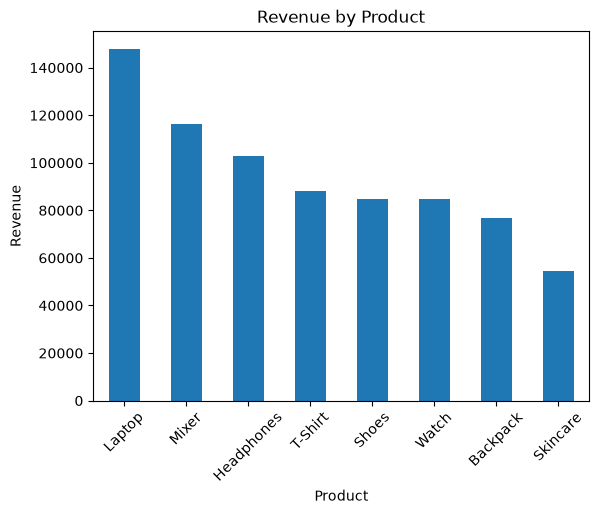

In [178]:
product_revenue.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [179]:
#21.3 — Profit by product
product_profit = df.groupby("product")["profit"].sum().sort_values(ascending=False)
product_profit

product
Laptop        26671.12
Headphones    24676.81
T-Shirt       22085.17
Shoes         20164.99
Mixer         19995.00
Watch         18606.48
Backpack      15804.48
Skincare       7488.93
Name: profit, dtype: float64

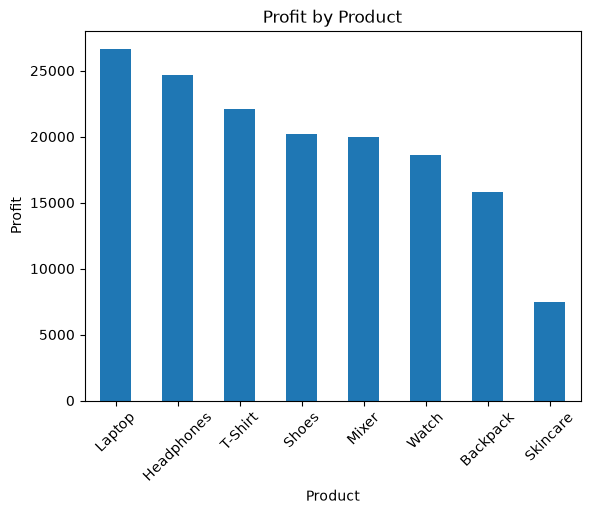

In [180]:
product_profit.plot(kind="bar")

plt.title("Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

## 11. Payment Method Analysis

Sales performance was analyzed across different payment methods using order volume, revenue, and profit.

This helps understand customer payment preferences and identify which payment methods contribute most to business performance.

In [181]:
#STEP 22 — Payment Method Analysis 💳

#22.1 — Orders by payment method
payment_orders=df["payment_method"].value_counts()
payment_orders

payment_method
Credit Card    46
UPI            40
Debit Card     38
Cash           25
Name: count, dtype: int64

In [182]:
#22.2 — Revenue by payment method

payment_revenue=df.groupby("payment_method")["revenue"].sum().sort_values(ascending=False)
payment_revenue

payment_method
Credit Card    264888.85
UPI            185991.55
Debit Card     182240.80
Cash           109763.05
Name: revenue, dtype: float64

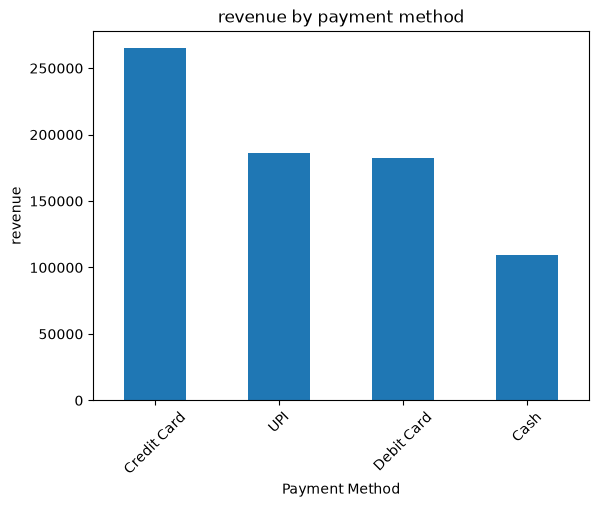

In [183]:
payment_revenue.plot(kind="bar")

plt.title("revenue by payment method")
plt.xlabel("Payment Method")
plt.ylabel("revenue")
plt.xticks(rotation=45)
plt.show()

In [184]:
#22.3 — Profit by payment method
payment_profit=df.groupby("payment_method")["profit"].sum().sort_values(ascending=False)
payment_profit

payment_method
Credit Card    50877.39
UPI            40389.93
Debit Card     33826.59
Cash           26129.91
Name: profit, dtype: float64

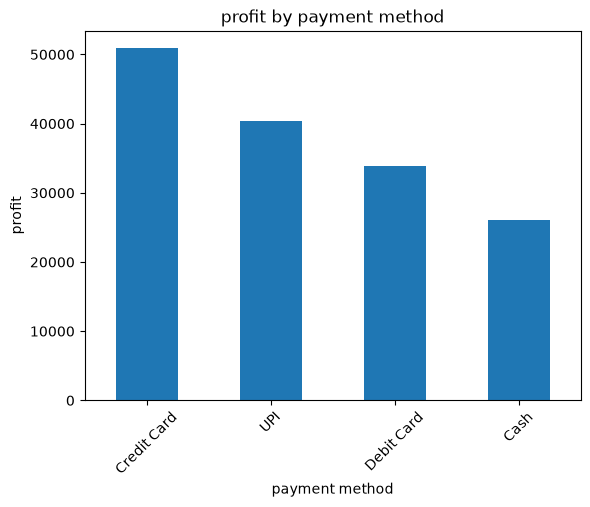

In [185]:
payment_profit.plot(kind="bar")
plt.title("profit by payment method")
plt.xlabel("payment method")
plt.ylabel("profit")
plt.xticks(rotation=45)
plt.show()

## 12. Sales Channel Analysis

Sales performance was analyzed across different sales channels using order volume, revenue, and profit.

This helps identify which channels contribute most to sales and profitability.

In [186]:
#STEP 23 — Sales Channel Analysis

#23.1 — Orders by channel
channel_orders=df["channel"].value_counts()
channel_orders


channel
Website       76
Mobile App    76
Name: count, dtype: int64

In [187]:
#23.2 — Revenue by channel
channel_revenue=df.groupby("channel")["revenue"].sum().sort_values(ascending=False)
channel_revenue

channel
Mobile App    394385.2
Website       361875.6
Name: revenue, dtype: float64

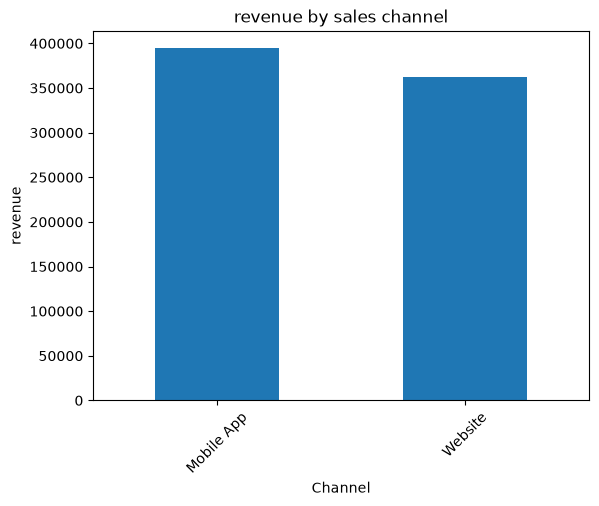

In [188]:
channel_revenue.plot(kind="bar")

plt.title("revenue by sales channel")
plt.xlabel("Channel")
plt.ylabel("revenue")
plt.xticks(rotation=45)
plt.show()

In [189]:
#23.3 — Profit by channel
channel_profit=df.groupby("channel")["profit"].sum().sort_values(ascending=False)
channel_profit

channel
Mobile App    84862.12
Website       70630.86
Name: profit, dtype: float64

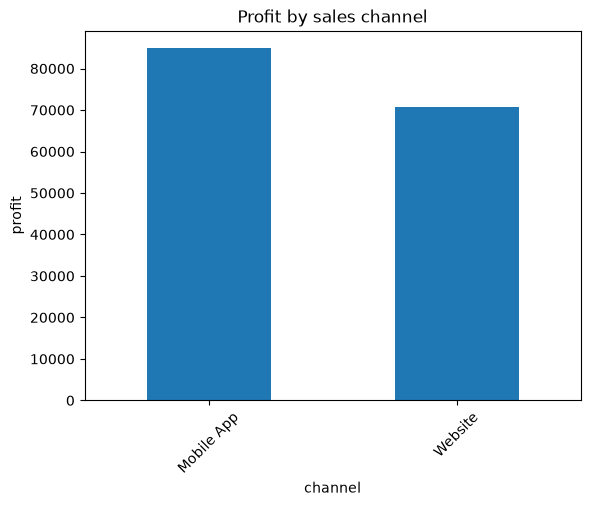

In [190]:
channel_profit.plot(kind="bar")
plt.title("Profit by sales channel")
plt.xlabel("channel")
plt.ylabel("profit")
plt.xticks(rotation=45)
plt.show()

## 13. Discount Analysis

The impact of different discount levels on revenue and profitability was analyzed.

Revenue and profit were compared across discount percentages to understand whether higher discounts are associated with lower profitability.

In [191]:
#STEP 24 — Discount Analysis
#24.1 — Check discount values

df["discount_pct"].value_counts().sort_index()

discount_pct
0     32
5     25
10    33
15    29
20    33
Name: count, dtype: int64

In [192]:
#24.2 — Revenue by discount level

discount_revenue=df.groupby("discount_pct")["revenue"].sum()
discount_revenue

discount_pct
0     193720.0
5     141783.7
10    161741.7
15    126769.0
20    132246.4
Name: revenue, dtype: float64

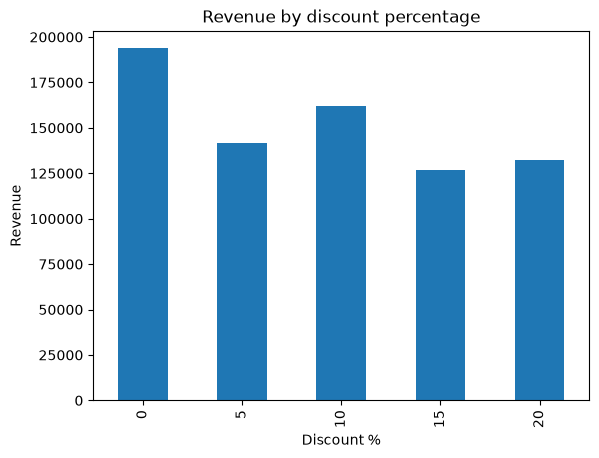

In [193]:
discount_revenue.plot(kind="bar")

plt.title("Revenue by discount percentage")
plt.xlabel("Discount %")
plt.ylabel("Revenue")
plt.show()

In [194]:
#24.3 — Profit by discount level

discount_profit=df.groupby("discount_pct")["profit"].sum()
discount_profit

discount_pct
0     54775.42
5     29891.60
10    31539.89
15    25033.57
20    14252.50
Name: profit, dtype: float64

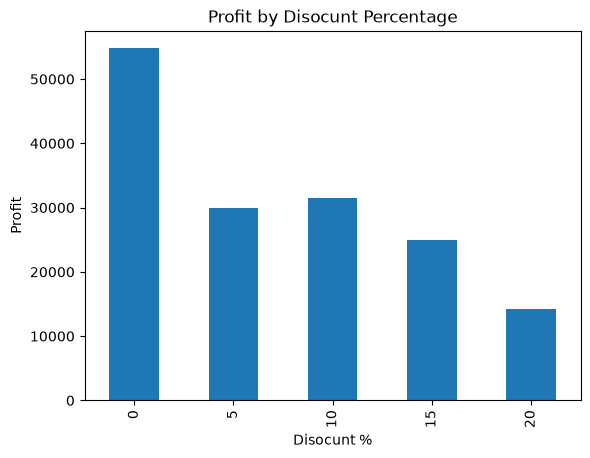

In [195]:
discount_profit.plot(kind="bar")

plt.title("Profit by Disocunt Percentage")
plt.xlabel("Disocunt %")
plt.ylabel("Profit")
plt.show()

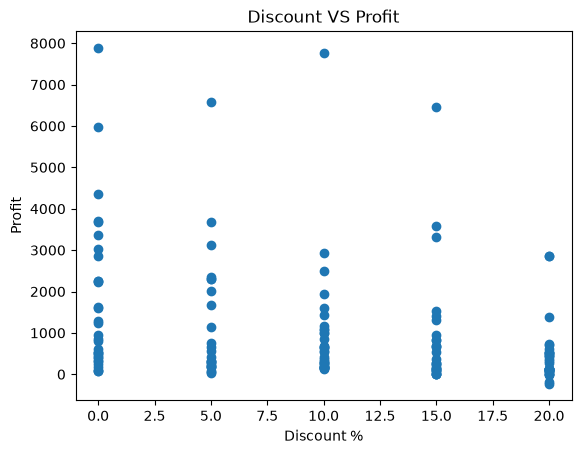

In [196]:
#STEP 25 — Discount vs Profit Relationship 📉💰
#Create a scatter plot

plt.scatter(df["discount_pct"],df["profit"])

plt.title("Discount VS Profit")
plt.xlabel("Discount %")
plt.ylabel("Profit")
plt.show()


## 14. Loss-Making Orders

Orders with negative profit were identified to investigate potential profitability issues.

These orders were reviewed based on revenue, cost, discount, category, and product to understand possible reasons for the losses.

In [197]:
#STEP 26 — Find Loss-Making Orders

#1️⃣ Filter orders where profit is negative

loss_orders=df[df["profit"]<0]
loss_orders

,order_id,order_date,customer_id,city,category,product,quantity,unit_price,payment_method,channel,discount_pct,revenue,cost,profit,month
7,1008,2026-04-13,544,Mumbai,Beauty,Headphones,2,799,NaN,Website,20,1278.4,1281.49,-3.09,2026-04
32,1033,2026-06-24,551,Bhubaneswar,Clothing,Backpack,4,299,Cash,Website,20,956.8,962.11,-5.31,2026-06
53,1054,2026-04-02,537,Pune,Beauty,Laptop,2,2499,Credit Card,Mobile App,20,3998.4,4226.36,-227.96,2026-04
110,1111,2026-02-02,532,Mumbai,Electronics,Mixer,1,299,Debit Card,Website,20,239.2,250.13,-10.93,2026-02
133,1134,2026-03-04,526,Bhubaneswar,Electronics,Mixer,1,4999,Credit Card,Mobile App,20,3999.2,4186.42,-187.22,2026-03


In [198]:
#2️⃣ Count how many loss-making orders exist

loss_orders.shape[0]

5

In [199]:
#3️⃣ Look at the important details

loss_orders[[
    "order_id",
     "category",
    "product",
    "discount_pct",
    "revenue",
    "cost",
    "profit"
]]

,order_id,category,product,discount_pct,revenue,cost,profit
7,1008,Beauty,Headphones,20,1278.4,1281.49,-3.09
32,1033,Clothing,Backpack,20,956.8,962.11,-5.31
53,1054,Beauty,Laptop,20,3998.4,4226.36,-227.96
110,1111,Electronics,Mixer,20,239.2,250.13,-10.93
133,1134,Electronics,Mixer,20,3999.2,4186.42,-187.22


## 15. Revenue vs Profit Analysis

The relationship between revenue and profit was analyzed using a scatter plot.

This helps identify whether high-revenue orders also generate high profits and highlights high-revenue orders with relatively low profitability.

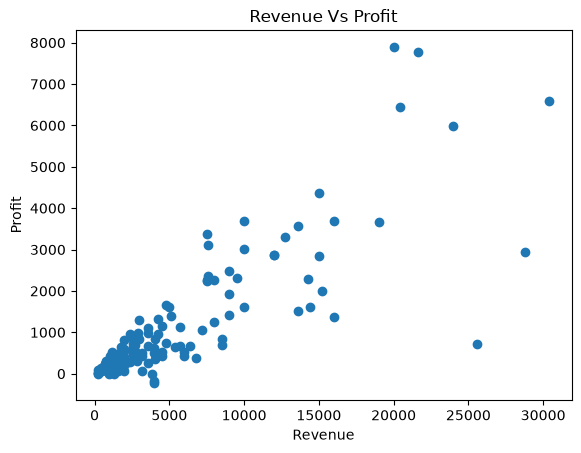

In [200]:
#STEP 27 — Revenue vs Profit Relationship.
#1️⃣ Create a scatter plot

plt.scatter(df["revenue"],df["profit"])

plt.title("Revenue Vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.show()

## 16. Correlation Analysis

Correlation analysis was performed to understand the relationships between key numerical variables such as quantity, unit price, discount, revenue, cost, and profit.

A correlation heatmap was used to visualize the strength and direction of these relationships.

In [201]:
#STEP 28 — Correlation Analysis

#1️⃣ Select the important numerical columns
numeric_cols=[
    "quantity",
    "unit_price",
    "discount_pct",
    "revenue",
    "cost",
    "profit",
]
corr=df[numeric_cols].corr()
corr

,quantity,unit_price,discount_pct,revenue,cost,profit
quantity,1.000000,-0.110084,0.060135,0.295358,0.291601,0.244798
unit_price,-0.110084,1.000000,-0.103418,0.815105,0.805789,0.672127
discount_pct,0.060135,-0.103418,1.000000,-0.129186,-0.072349,-0.287862
revenue,0.295358,0.815105,-0.129186,1.000000,0.985707,0.833967
cost,0.291601,0.805789,-0.072349,0.985707,1.000000,0.729086
profit,0.244798,0.672127,-0.287862,0.833967,0.729086,1.000000


In [202]:
!pip install seaborn

mambajs 0.21.4

Process pip requirements ...

Requirement seaborn already satisfied.


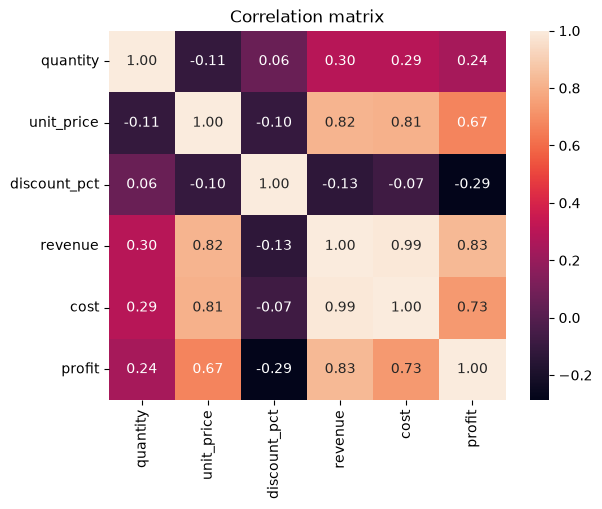

In [203]:
#3️⃣ Optional: Make it visual with a heatmap

import seaborn as sns

sns.heatmap(corr,annot=True,fmt=".2f")

plt.title("Correlation matrix")
plt.show()

### Key Finding

Revenue and profit show a strong positive correlation, while discount and profit show a negative relationship. These relationships help identify factors associated with business profitability.

## 17. Data Validation

The dataset was validated to identify potential data-quality issues and ensure that important business calculations are consistent.

Validation checks included:

- Missing values
- Duplicate records
- Invalid numerical values
- Discount range
- Negative revenue
- Profit calculation consistency

In [204]:
#STEP 29 — Data Cleaning & Validation
#1️⃣ Check missing values

df.isnull().sum()


order_id          0
order_date        0
customer_id       0
city              2
category          0
product           0
quantity          0
unit_price        0
payment_method    3
channel           0
discount_pct      0
revenue           0
cost              0
profit            0
month             0
dtype: int64

In [205]:
#2️⃣ Check duplicate rows

df.duplicated().sum()

np.int64(2)

In [206]:
#3️⃣ Check for invalid quantities

(df["quantity"]<=0).sum()

np.int64(0)

In [207]:
#4️⃣ Check discount range

print("negative discounts:",(df["discount_pct"]<0).sum())
print("Discounts above 100%:",(df["discount_pct"]>100).sum())

negative discounts: 0
Discounts above 100%: 0


In [208]:
#5️⃣ Check negative revenue

(df["revenue"]<0).sum()

np.int64(0)

In [209]:
#6️⃣ Check whether the profit formula is correct

((df["revenue"]-df["cost"]-df["profit"]).abs()>0.01).sum()

np.int64(0)

In [210]:
#STEP 30 — Final Business Insights & Recommendations

#1️⃣ Calculate the main KPIs

total_revenue=df["revenue"].sum()
total_profit=df["profit"].sum()
total_orders=df["order_id"].nunique()
avg_order_value=df["revenue"].mean()
profit_margin=(total_profit/total_revenue)*100

print("Total Revenue:",total_revenue)
print("Total profit:",total_profit)
print("Total Orders:",total_orders)
print("Average Order Value:",avg_order_value)
print("Profit Margin:",profit_margin, "%")

Total Revenue: 756260.7999999999
Total profit: 155492.98
Total Orders: 150
Average Order Value: 4975.4
Profit Margin: 20.560761578545396 %


In [211]:
#2️⃣ Find the best category

category_revenue.idxmax(),category_revenue.max()


('Beauty', np.float64(249267.9))

In [212]:
category_profit.idxmax(),category_profit.max()

('Beauty', np.float64(51512.88))

In [213]:
#3️⃣ Find the best city

city_revenue.idxmax(),city_revenue.max()
city_profit.idxmax(),city_profit.max()

('Pune', np.float64(55399.03))

In [214]:
#4️⃣ Find the best product

product_revenue.idxmax(),product_revenue.max()
product_profit.idxmax(),product_profit.max()

('Laptop', np.float64(26671.120000000003))

In [215]:
#5️⃣ Find the most profitable discount level

discount_profit.idxmax(),discount_profit.max()

(np.int64(0), np.float64(54775.42))

## 18. Business Insights & Recommendations

### Key Insights

- Revenue is right-skewed, with a small number of high-value orders contributing significantly to total sales.
- Profitability varies across individual orders, including some loss-making orders.
- Revenue and profit have a strong positive relationship.
- Revenue and cost have an extremely strong positive relationship.
- Higher discount levels show a negative relationship with profit.
- High-revenue orders should be evaluated based on profit as well as sales value.

### Business Recommendations

1. Monitor high-discount orders to protect profit margins.
2. Focus on products and categories that generate strong profitability.
3. Investigate loss-making orders to identify pricing, cost, or discount issues.
4. Monitor high-revenue but low-profit orders.
5. Analyze high-cost products to identify opportunities to improve margins.
6. Use city and sales-channel performance to support better marketing and sales decisions.

### Conclusion

This analysis demonstrates an end-to-end exploratory data analysis workflow using Python and provides actionable insights that can support data-driven business decisions.